In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [49]:
df = pd.read_csv('../data/raw/dataset_revision.csv')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [51]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [52]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [53]:
# cambiar nombre a columna tenure
df.rename(columns={'tenure': 'Antiguedad'}, inplace=True)

In [54]:
#Quitamos los 0 en antiguedad multiplicando monthly y antguedad, quedaran a 0 los que tambine llevan 0 meses
mask = df['TotalCharges'] == 0
df.loc[mask, 'TotalCharges'] = (df['MonthlyCharges'] * df['Antiguedad'])

In [55]:
#Quitamos los 0 en antiguedad y lo dividimos por los cargos mensuales
mask = df['Antiguedad'] == 0
df.loc[mask, 'Antiguedad'] = (df['TotalCharges'] / df['MonthlyCharges']).astype(int)

In [56]:
df.Antiguedad.describe()

count    7043.000000
mean       32.441431
std        24.546661
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Antiguedad, dtype: float64

In [57]:
df.MonthlyCharges.describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [58]:
#CALCULO TASA DE ABANDONO
churn_counts = df['Churn'].value_counts()
churn_rate = (churn_counts['Yes'] / len(df)) * 100
print(f"Tasa de Churn Global: {churn_rate:.2f}%")

Tasa de Churn Global: 26.54%


In [59]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [60]:
print(df['Antiguedad'].mean())
print(df['MonthlyCharges'].mean())
print(df['TotalCharges'].mean())


32.441431208291924
64.76169246059918
2281.9169281556156


/tmp/ipykernel_13090/24405446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='Churn', palette='Set2')


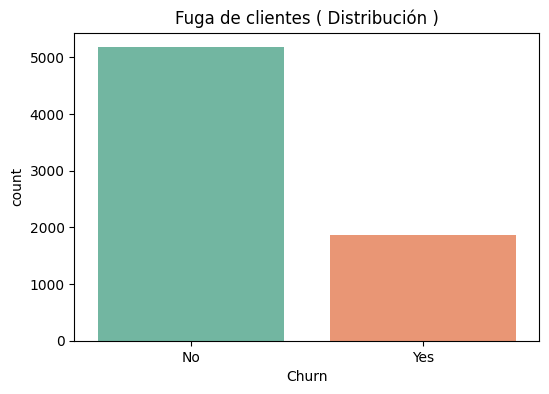

In [61]:
# FUGA DE CLIENTES CHURN RATE
plt.figure(figsize=(6, 4))
sns.countplot(df, x='Churn', palette='Set2')
plt.title('Fuga de clientes ( Distribución )')
plt.show()

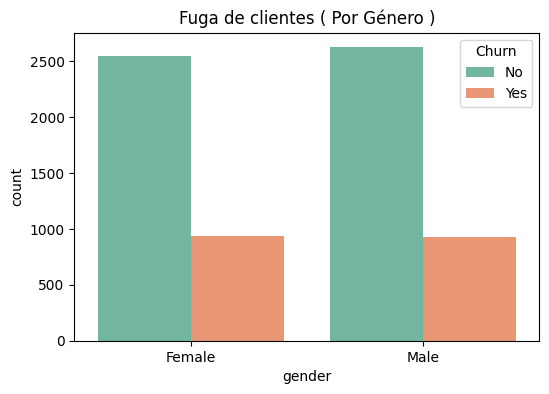

In [62]:
# HOMBRES O MUJERES?
plt.figure(figsize=(6, 4))
sns.countplot(df, x='gender', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por Género )')
plt.show()

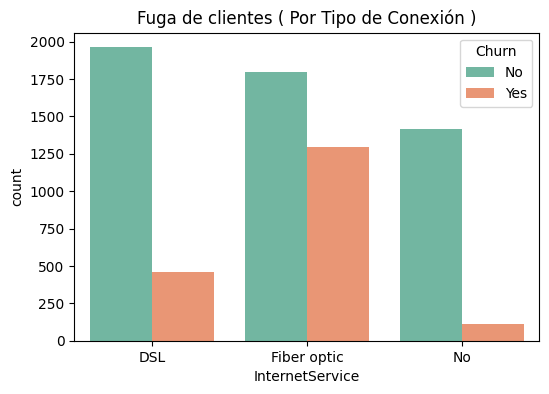

In [63]:
# FUGA POR TIPO DE CONEXION
plt.figure(figsize=(6, 4))
sns.countplot(df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por Tipo de Conexión )')
plt.show()

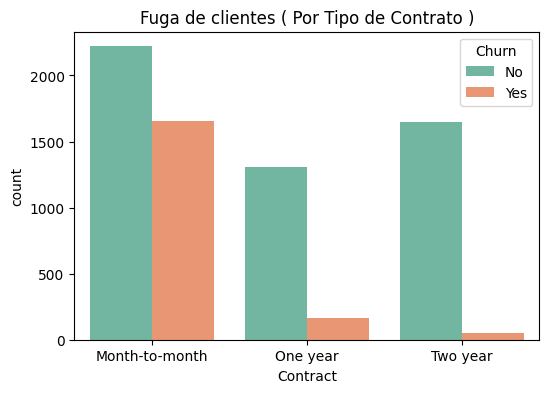

In [64]:
# FUGA POR TIPO DE CONTRATO
plt.figure(figsize=(6, 4))
sns.countplot(df, x='Contract', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por Tipo de Contrato )')
plt.show()

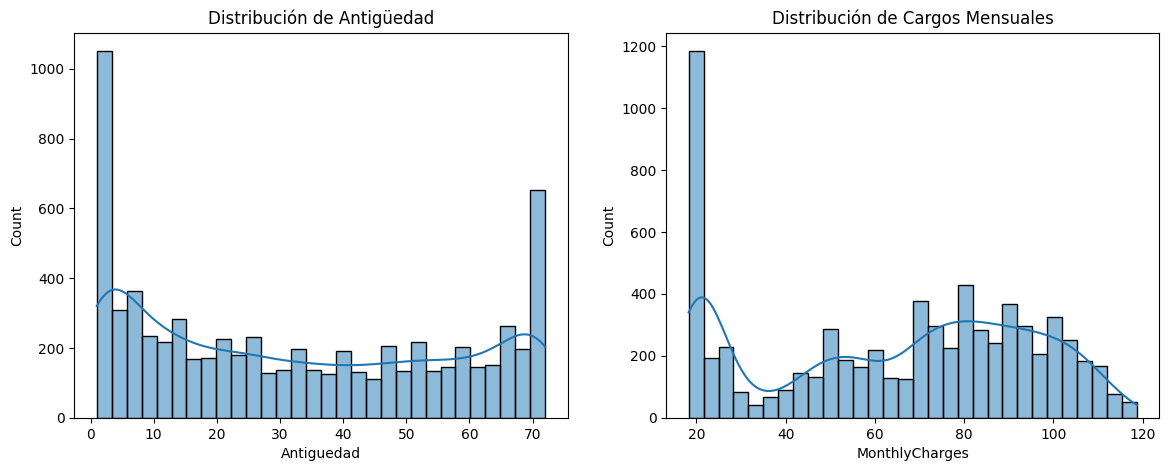

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Antiguedad'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Distribución de Antigüedad')

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=ax[1])
ax[1].set_title('Distribución de Cargos Mensuales')
plt.show()

In [66]:
service_columns = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Función para contar servicios activos
def count_services(row):
    count = 0
    if row['PhoneService'] == 'Yes': count += 1
    if row['MultipleLines'] == 'Yes': count += 1
    if row['InternetService'] in ['DSL', 'Fiber optic']: count += 1
    for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
        if row[col] == 'Yes': count += 1
    return count

# Crear la nueva columna
df['TotalServices'] = df.apply(count_services, axis=1)

In [67]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,Antiguedad,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServices
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,4
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,8
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,7
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,2
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,3


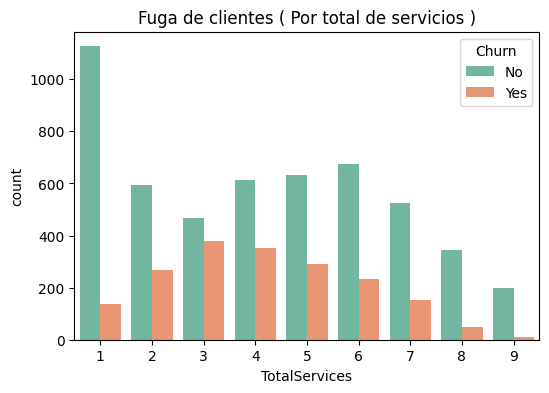

In [68]:
# FUGA POR TIPO DE CONTRATO
plt.figure(figsize=(6, 4))
sns.countplot(df, x='TotalServices', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por total de servicios )')
plt.show()

In [69]:
df['g_antiguedad'] = pd.cut(df['Antiguedad'], 
                     bins=[0, 12, 24, 48, np.inf], 
                     labels=['Hasta 12 meses', '12 a 24', '24 a 48', 'Más de 48'])

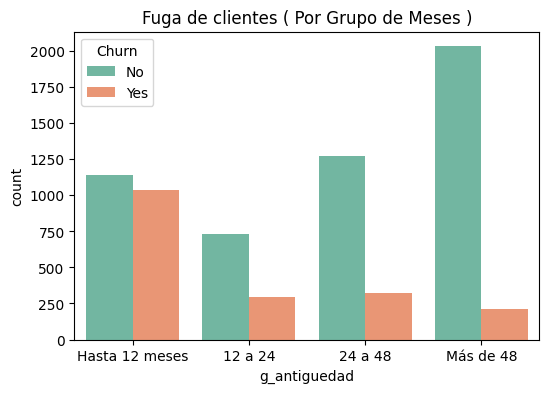

In [70]:
# FUGA POR MESES
plt.figure(figsize=(6, 4))
sns.countplot(df, x='g_antiguedad', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por Grupo de Meses )')
plt.show()

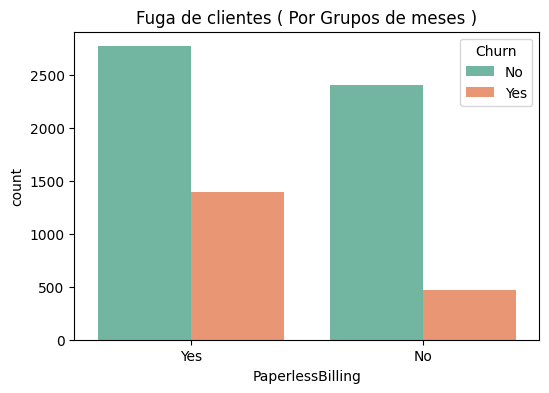

In [71]:
# FUGA POR PAPERLESS BILLING
plt.figure(figsize=(6, 4))
sns.countplot(df, x='PaperlessBilling', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por Grupos de meses )')
plt.show()

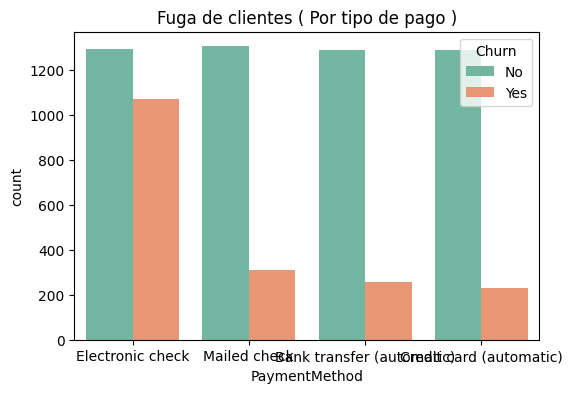

In [72]:
# FUGA POR PAPERLESS BILLING
plt.figure(figsize=(6, 4))
sns.countplot(df, x='PaymentMethod', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( Por tipo de pago )')
plt.show()

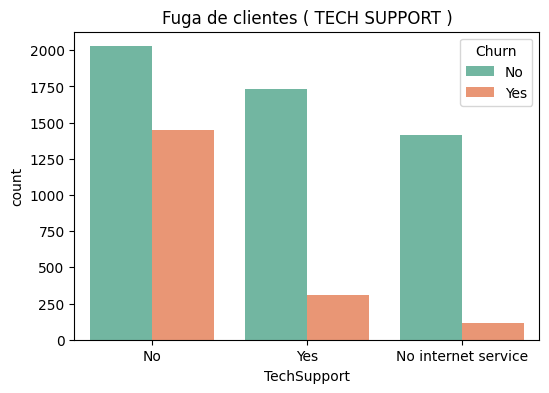

In [73]:
# FUGA POR TECHSUPPORT
plt.figure(figsize=(6, 4))
sns.countplot(df, x='TechSupport', hue='Churn', palette='Set2')
plt.title('Fuga de clientes ( TECH SUPPORT )')
plt.show()

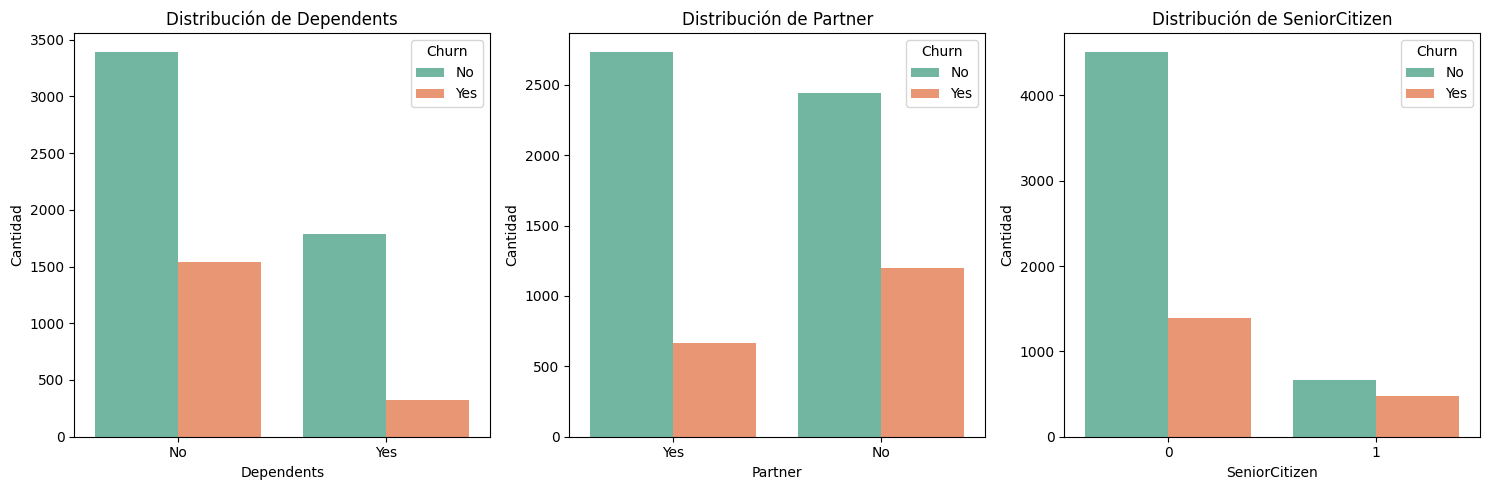

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

columnas = ['Dependents', 'Partner', 'SeniorCitizen']

for i, col in enumerate(columnas):
    sns.countplot(data=df, x=col, hue='Churn', palette='Set2', ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

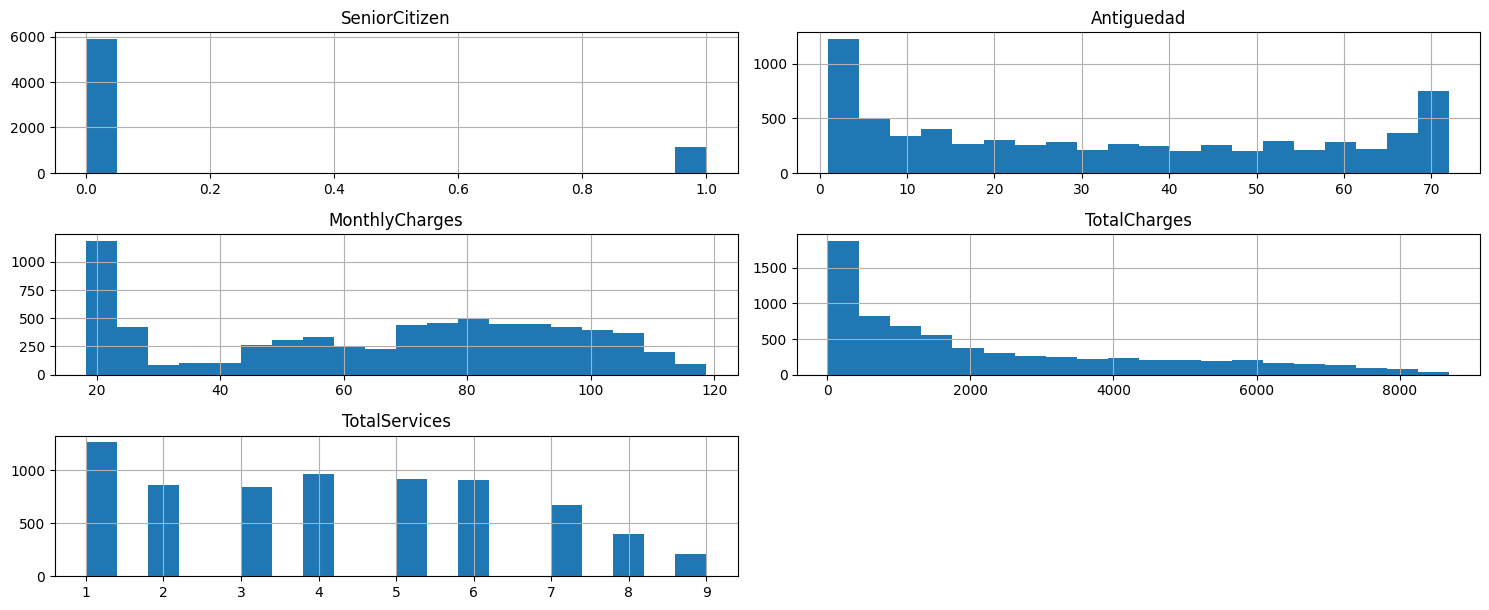

In [75]:
df.hist(bins=20, figsize=(15, 10), layout=(5, 2))
plt.tight_layout() # Para que no se encabalguen las etiquetas
plt.show()

In [76]:
df.to_csv('../data/processed/dataset_final_grupos.csv', index=False)

In [77]:
#eliminamos customerID que no nos dice nada
df = df.drop(columns=['customerID'])
#eliminamos el grupo que no lo vamos a nacesitar
df = df.drop(columns=['g_antiguedad'])
#eliminamos  numero total de servicios, solo se ha creado para ver si cuanto más mejor
df = df.drop(columns=['TotalServices'])


In [78]:
df.to_csv('../data/processed/dataset_final.csv', index=False)